# 2. 유트브 랭킹 사이트 시각화

- 목표: 유튜브 랭킹 사이트의 채널 데이터를 수집하고 분석하여 시각화한다.
- 처리:
  1. Selenium을 이용하여 유튜브 랭킹 사이트에서 카테고리, 제목, 구독자 등 200개 이상의 채널 정보를 크롤링한다.
  2. 크롤링한 데이터를 데이터프레임으로 저장한다.
  3. 저장된 데이터를 카테고리별로 분석한다.
- 결과: 분석된 데이터를 파이 차트 등의 그래프로 시각화하여 제공한다.

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

## 1. 크롤링 함수 정의

In [3]:
def hangle_to_number(text):
    num = 0
    if ',' in text:
        text = text.replace(',', '')
    if '조' in text:
        temp = text.split('조')
        text = temp[1]
        num += int(temp[0]) * 1000000000000
    if '억' in text:
        temp = text.split('억')
        text = temp[1]
        num += int(temp[0]) * 100000000
    if '만' in text:
        temp = text.split('만')
        text = temp[1]
        num += int(temp[0]) * 10000
    if text != '':
        num += int(text)
    return num
def crawl_youtube_ranking(from_page=1, to_page=1):
    driver = webdriver.Chrome(service=ChromeService(ChromeDriverManager().install()))
    data = []

    for i in range(from_page, to_page + 1):
        url = f'https://youtube-rank.com/board/bbs/board.php?bo_table=youtube&page={i}'
        driver.get(url)

        # 원하는 데이터가 포함된 CSS 선택자
        SELECTOR = (By.CSS_SELECTOR, "section#list-skin table tbody tr.aos-init")

        # 최대 10초 동안 해당 요소가 나타날 때까지 기다림
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located(SELECTOR)
        )

        html_source = driver.page_source
        soup = BeautifulSoup(html_source, 'html.parser')
        channel_list = soup.select('section#list-skin table tbody tr.aos-init')
        for channel in channel_list:
            rank = channel.select_one('td.rank').text.strip()
            category = channel.select_one('td.subject > h1 > p.category').text.strip().replace('[', '').replace(']', '')
            name = channel.select_one('td.subject > h1 > a').text.strip()
            subscriber_cnt = hangle_to_number(channel.select_one('td.subscriber_cnt').text.strip())
            view_cnt = hangle_to_number(channel.select_one('td.view_cnt').text.strip())
            video_cnt = hangle_to_number(channel.select_one('td.video_cnt').text.strip().replace('개', ''))
        
            data.append({
                'rank': rank,
                'category': category,
                'name': name,
                'subscriber_cnt': subscriber_cnt,
                'view_cnt': view_cnt,
                'video_cnt': video_cnt
            })
        time.sleep(0.5)
    driver.quit()
    return data

## 2. 데이터 수집 및 전처리

In [14]:
youtube_data = crawl_youtube_ranking(1, 1)

df = pd.DataFrame(youtube_data)

# 데이터 확인
print("전체 데이터 개수:", len(df))
df.head()

전체 데이터 개수: 100


,rank,category,name,subscriber_cnt,view_cnt,video_cnt
0,1,BJ/인물/연예인,김프로KIMPRO,126000000,121896750000,3690
1,2,음악/댄스/가수,BLACKPINK,99400000,40772800000,641
2,3,음악/댄스/가수,BANGTANTV,81800000,26052130000,2947
3,4,음악/댄스/가수,HYBE LABELS,79200000,42682130000,2933
4,5,미분류,Justin Bieber,76600000,36670360000,278


## 3. 데이터 시각화

In [15]:
category_group = df.groupby('category')

In [16]:
# 카테고리 개수를 2% 이하로 합치기
def aggregate_small_categories(counts: pd.Series, threshold_percentage: float = 0.02) -> pd.Series:
    total_sum = counts.sum()
    threshold = threshold_percentage * total_sum

    small_categories = counts[counts < threshold]
    large_categories = counts[counts >= threshold]

    if not small_categories.empty:
        other_sum = small_categories.sum()
        other_series = pd.Series({'기타': other_sum})
        return pd.concat([large_categories, other_series])
    else:
        return large_categories


### 3-1. 카테고리 별 상위 300개 채널 개수/비율

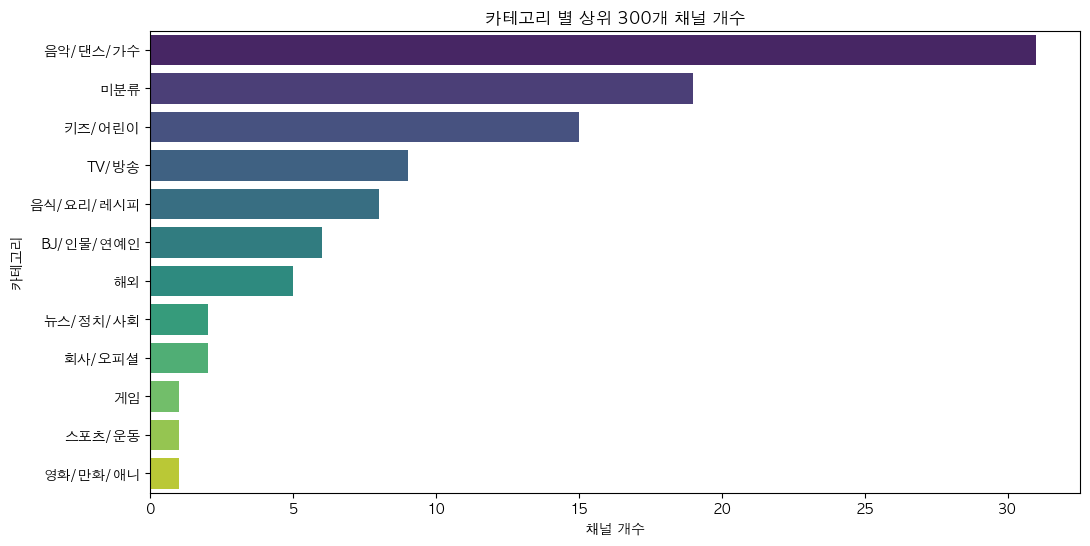

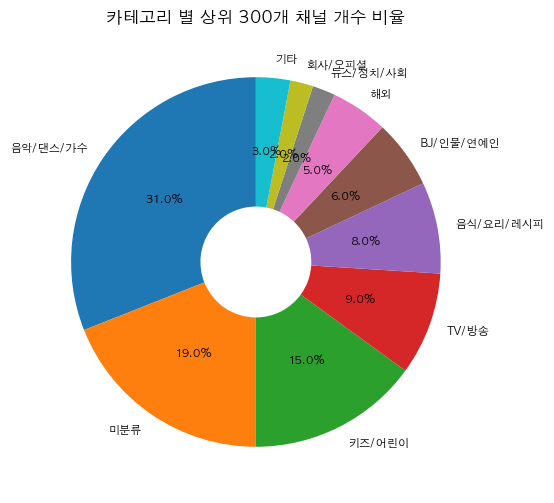

In [17]:
channel_cnt = category_group.size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=channel_cnt.values, y=channel_cnt.index, palette='viridis', legend=False, hue=channel_cnt.index)
plt.title('카테고리 별 상위 300개 채널 개수')
plt.xlabel('채널 개수')
plt.ylabel('카테고리')
plt.show()

channel_cnt = aggregate_small_categories(channel_cnt)

plt.figure(figsize=(12, 6))
plt.pie(
    x=channel_cnt.values,
    labels=channel_cnt.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.7},
    textprops={'fontsize': 8},
)
plt.title('카테고리 별 상위 300개 채널 개수 비율')
plt.show()

### 3-2. 카테고리 별 상위 300개 채널 구독자 수/비율

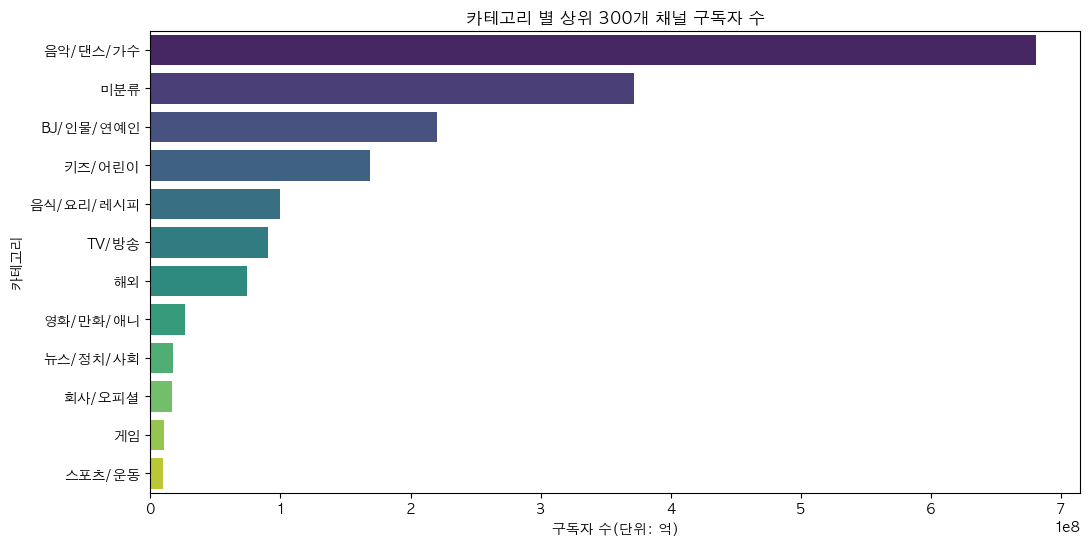

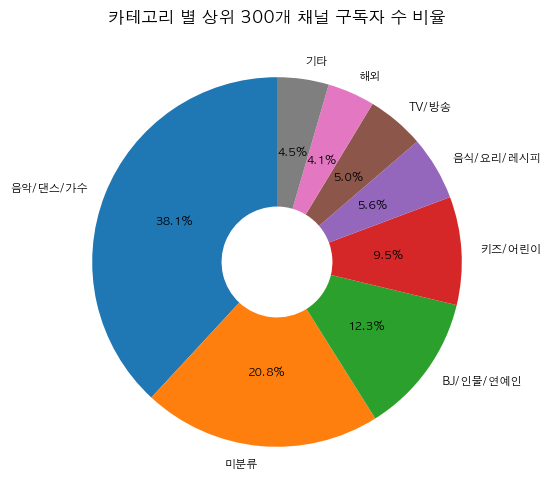

In [18]:
sub_cnt = category_group['subscriber_cnt'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sub_cnt.values, y=sub_cnt.index, palette='viridis', legend=False, hue=sub_cnt.index)
plt.title('카테고리 별 상위 300개 채널 구독자 수')
plt.xlabel('구독자 수(단위: 억)')
plt.ylabel('카테고리')
plt.show()

# 카테고리 개수를 2% 이하로 합치기
sub_cnt = aggregate_small_categories(sub_cnt)

plt.figure(figsize=(12, 6))
plt.pie(
    x=sub_cnt.values,
    labels=sub_cnt.index,
    autopct='%1.1f%%',
    startangle=90,
    # autopct 비율을 1.25 (파이 반지름의 125%) 위치에 표시
    # pctdistance=1.25,
    # 파이 조각 너비를 줄여 도넛 형태로 만들고 여백 확보
    wedgeprops={'width': 0.7},
    # 폰트 크기를 8로 줄입니다.
    textprops={'fontsize': 8},
)
plt.title('카테고리 별 상위 300개 채널 구독자 수 비율')
plt.show()

### 3-3. 카테고리 별 상위 300개 채널 View 수/비율

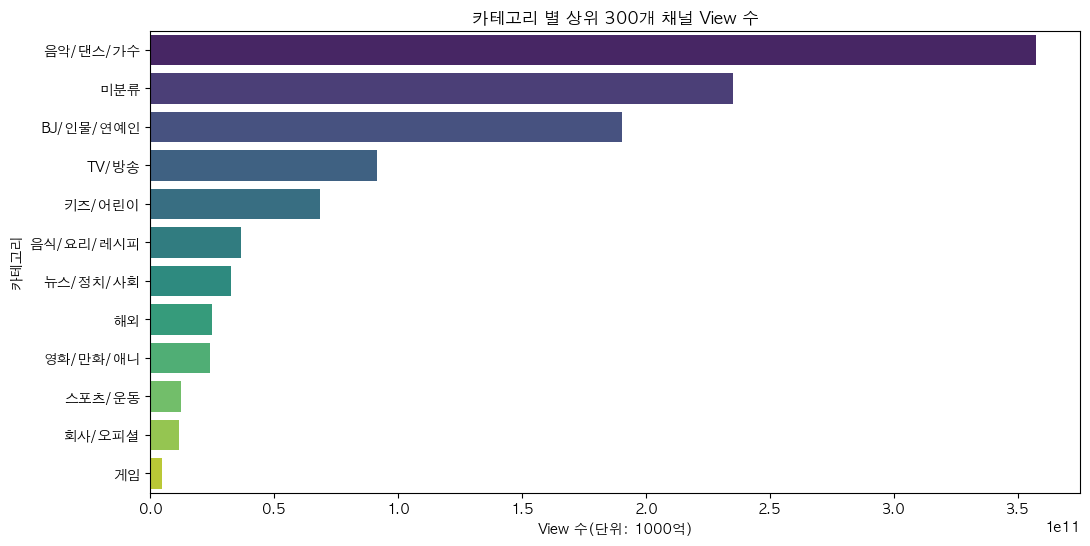

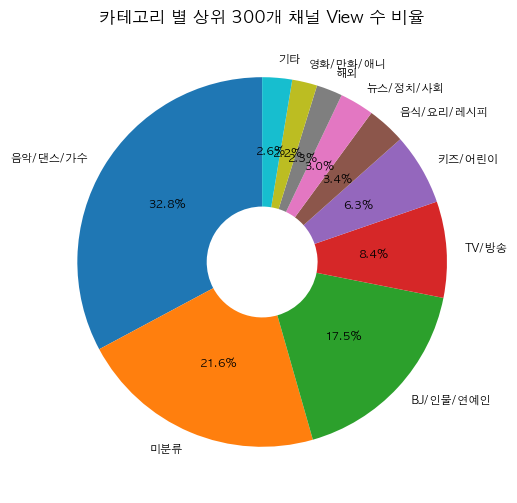

In [19]:
view_cnt = category_group['view_cnt'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=view_cnt.values, y=view_cnt.index, palette='viridis', legend=False, hue=view_cnt.index)
plt.title('카테고리 별 상위 300개 채널 View 수')
plt.xlabel('View 수(단위: 1000억)')
plt.ylabel('카테고리')
plt.show()

# 카테고리 개수를 2% 이하로 합치기
view_cnt = aggregate_small_categories(view_cnt)

plt.figure(figsize=(12, 6))
plt.pie(
    x=view_cnt.values,
    labels=view_cnt.index,
    autopct='%1.1f%%',
    startangle=90,
    # autopct 비율을 1.25 (파이 반지름의 125%) 위치에 표시
    # pctdistance=1.25,
    # 파이 조각 너비를 줄여 도넛 형태로 만들고 여백 확보
    wedgeprops={'width': 0.7},
    # 폰트 크기를 8로 줄입니다.
    textprops={'fontsize': 8},
)
plt.title('카테고리 별 상위 300개 채널 View 수 비율')
plt.show()

### 3-4. 카테고리 별 상위 300개 채널 Video 수/비율

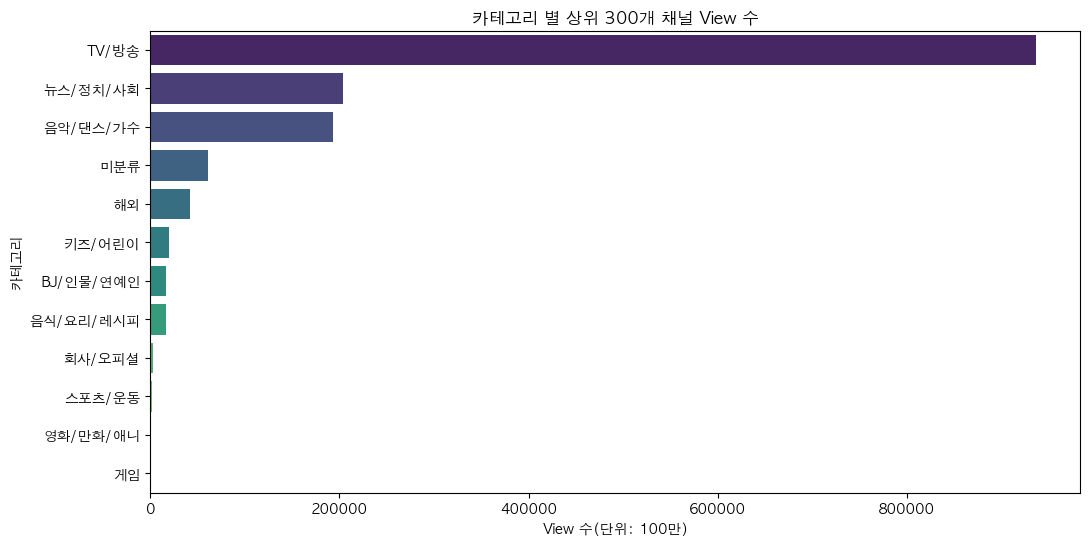

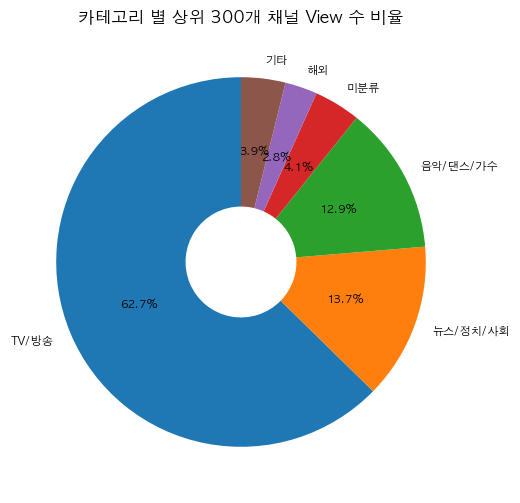

In [20]:
video_cnt = category_group['video_cnt'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=video_cnt.values, y=video_cnt.index, palette='viridis', legend=False, hue=video_cnt.index)
plt.title('카테고리 별 상위 300개 채널 View 수')
plt.xlabel('View 수(단위: 100만)')
plt.ylabel('카테고리')
plt.show()

# 카테고리 개수를 2% 이하로 합치기
video_cnt = aggregate_small_categories(video_cnt)

plt.figure(figsize=(12, 6))
plt.pie(
    x=video_cnt.values,
    labels=video_cnt.index,
    autopct='%1.1f%%',
    startangle=90,
    # autopct 비율을 1.25 (파이 반지름의 125%) 위치에 표시
    # pctdistance=1.25,
    # 파이 조각 너비를 줄여 도넛 형태로 만들고 여백 확보
    wedgeprops={'width': 0.7},
    # 폰트 크기를 8로 줄입니다.
    textprops={'fontsize': 8},
)
plt.title('카테고리 별 상위 300개 채널 View 수 비율')
plt.show()

### 3-5. 구독자 수와 View 수의 상관관계

<Figure size 1000x600 with 0 Axes>

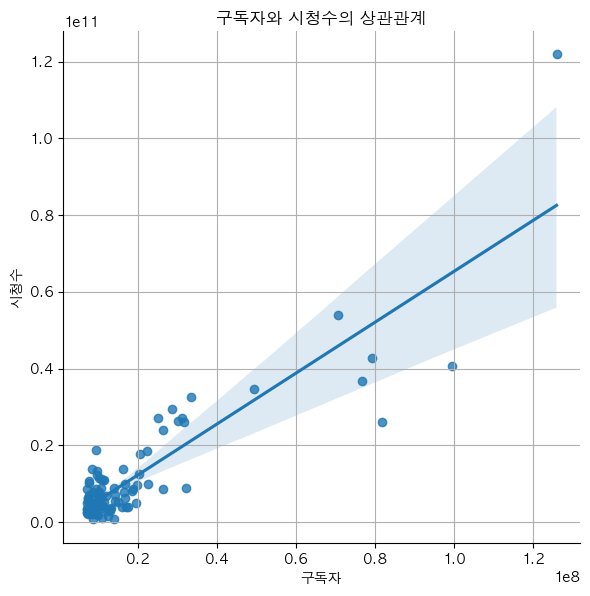

구독자와 시청수의 상관관계: 0.88


In [21]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='subscriber_cnt', y='view_cnt', data=df, height=6)
plt.title('구독자와 시청수의 상관관계')
plt.xlabel('구독자')
plt.ylabel('시청수')
plt.grid(True)
plt.show()

correlation = df['subscriber_cnt'].corr(df['view_cnt'])
print(f"구독자와 시청수의 상관관계: {correlation:.2f}")


### 3-6. 구독자 수와 Video 수의 상관관계

<Figure size 1000x600 with 0 Axes>

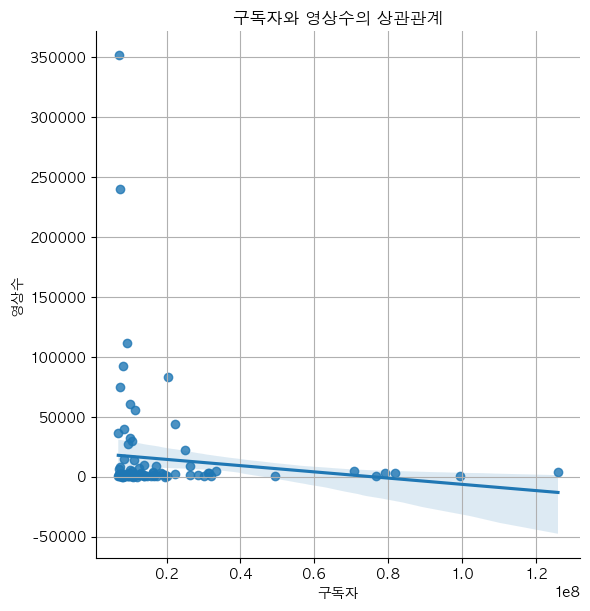

구독자와 영상수의 상관관계: -0.11


In [22]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='subscriber_cnt', y='video_cnt', data=df, height=6)
plt.title('구독자와 영상수의 상관관계')
plt.xlabel('구독자')
plt.ylabel('영상수')
plt.grid(True)
plt.show()

correlation = df['subscriber_cnt'].corr(df['video_cnt'])
print(f"구독자와 영상수의 상관관계: {correlation:.2f}")


### 3-7. View 수와 Video 수의 상관관계

<Figure size 1000x600 with 0 Axes>

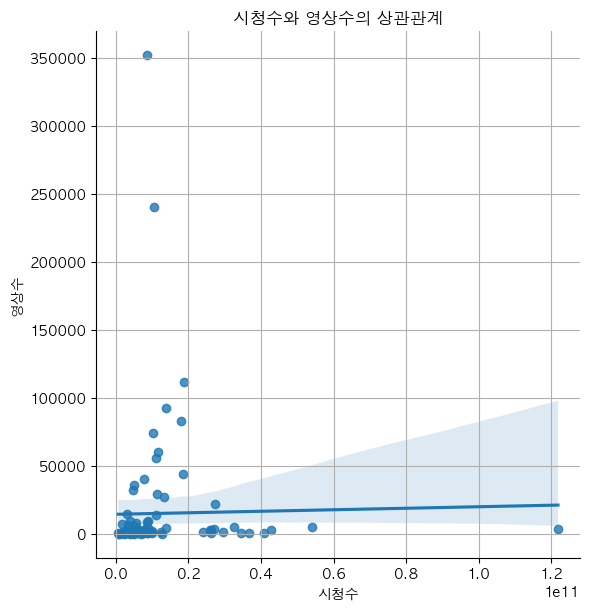

시청수와 영상수의 상관관계: 0.02


In [23]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='view_cnt', y='video_cnt', data=df, height=6)
plt.title('시청수와 영상수의 상관관계')
plt.xlabel('시청수')
plt.ylabel('영상수')
plt.grid(True)
plt.show()

correlation = df['view_cnt'].corr(df['video_cnt'])
print(f"시청수와 영상수의 상관관계: {correlation:.2f}")
